In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# verify GPU
import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Mounted at /content/drive
GPU available: False
Device: CPU


In [ ]:
!pip install transformers datasets scikit-learn pandas numpy -q

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paths ──────────────────────────────────────────────────────────────
DRIVE_PATH = '/content/drive/MyDrive/hate-speech-project'
DATA_PATH  = os.path.join(DRIVE_PATH, 'data')
MODEL_PATH = os.path.join(DRIVE_PATH, 'models')
os.makedirs(DATA_PATH,  exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

# ── Settings ───────────────────────────────────────────────────────────
MODEL_NAME   = 'roberta-base'
MAX_LENGTH   = 128
BATCH_SIZE   = 32
EPOCHS       = 4
LEARNING_RATE = 2e-5
NUM_CLASSES  = 3
LABEL_NAMES  = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cuda


In [ ]:
train_df = pd.read_csv(os.path.join(DATA_PATH, 'train_clean.csv'))
val_df   = pd.read_csv(os.path.join(DATA_PATH, 'val_clean.csv'))
test_df  = pd.read_csv(os.path.join(DATA_PATH, 'test_clean.csv'))

# Drop empty rows from preprocessing
for df in [train_df, val_df, test_df]:
    df.dropna(subset=['clean_text'], inplace=True)
    df.drop(index=df[df['clean_text'].str.strip() == ''].index,
            inplace=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nClass distribution (train):")
print(train_df['label'].value_counts().sort_index()
      .rename(index=LABEL_NAMES))

Train: 17345 | Val: 3718 | Test: 3717

Class distribution (train):
label
Hate Speech            1001
Offensive Language    13431
Neither                2913
Name: count, dtype: int64


In [ ]:
class HateSpeechDataset(Dataset):
    """
    PyTorch Dataset for hate speech classification.

    __len__  : returns total number of samples
    __getitem__ : returns one sample as tokenized tensors
    """
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Create datasets
train_dataset = HateSpeechDataset(
    train_df['clean_text'].tolist(),
    train_df['label'].tolist(),
    tokenizer, MAX_LENGTH
)
val_dataset = HateSpeechDataset(
    val_df['clean_text'].tolist(),
    val_df['label'].tolist(),
    tokenizer, MAX_LENGTH
)
test_dataset = HateSpeechDataset(
    test_df['clean_text'].tolist(),
    test_df['label'].tolist(),
    tokenizer, MAX_LENGTH
)

# Create DataLoaders — these feed data in batches during training
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 543


In [ ]:
# Compute class weights for imbalance
classes = np.array([0, 1, 2])
weights = compute_class_weight(
    'balanced',
    classes=classes,
    y=train_df['label'].tolist()
)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print(f"Class weights: {dict(zip(LABEL_NAMES.values(), weights.round(2)))}")

# Load RoBERTa with classification head
# num_labels=3 adds a linear layer on top for 3-class classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)
model = model.to(device)

# Optimizer — AdamW is standard for transformer fine-tuning
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                               weight_decay=0.01)

# Learning rate scheduler — gradually reduces LR during training
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = total_steps // 10   # 10% warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Loss function with class weights to handle imbalance
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Total training steps: {total_steps}")

Class weights: {'Hate Speech': np.float64(5.78), 'Offensive Language': np.float64(0.43), 'Neither': np.float64(1.98)}


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 124,647,939
Total training steps: 2172


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    """One full pass through the training data."""
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Zero gradients from previous step
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask)
        logits  = outputs.logits

        # Compute loss
        loss = loss_fn(logits, labels)

        # Backward pass — compute gradients
        loss.backward()

        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update weights
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} "
                  f"— Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1


def evaluate_model(model, loader, loss_fn, device):
    """Evaluate on val or test set."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                           attention_mask=attention_mask)
            logits  = outputs.logits

            loss = loss_fn(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1       = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1, all_preds, all_labels

In [ ]:
print("Starting training...\n")

best_val_f1    = 0
best_model_path = os.path.join(MODEL_PATH, 'roberta_best.pt')
history        = {'train_loss': [], 'val_loss': [],
                  'train_f1': [],   'val_f1': []}

for epoch in range(1, EPOCHS + 1):
    print(f"{'='*55}")
    print(f"EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*55}")

    train_loss, train_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, loss_fn, device
    )
    val_loss, val_f1, val_preds, val_labels = evaluate_model(
        model, val_loader, loss_fn, device
    )

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    print(f"\nTrain — Loss: {train_loss:.4f} | Macro-F1: {train_f1:.4f}")
    print(f"Val   — Loss: {val_loss:.4f}   | Macro-F1: {val_f1:.4f}")

    # Hate speech F1 specifically
    val_hate_f1 = f1_score(val_labels, val_preds, average=None)[0]
    print(f"Val Hate Speech F1: {val_hate_f1:.4f}")

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"*** New best model saved (Val Macro-F1: {val_f1:.4f}) ***")

print(f"\nTraining complete. Best Val Macro-F1: {best_val_f1:.4f}")

Starting training...

EPOCH 1/4
  Batch 100/543 — Loss: 1.0241
  Batch 200/543 — Loss: 0.6062
  Batch 300/543 — Loss: 0.5314
  Batch 400/543 — Loss: 0.2224
  Batch 500/543 — Loss: 0.6659

Train — Loss: 0.7013 | Macro-F1: 0.6115
Val   — Loss: 0.4961   | Macro-F1: 0.7165
Val Hate Speech F1: 0.3812
*** New best model saved (Val Macro-F1: 0.7165) ***
EPOCH 2/4
  Batch 100/543 — Loss: 0.6489
  Batch 200/543 — Loss: 0.3705
  Batch 300/543 — Loss: 0.6536
  Batch 400/543 — Loss: 0.2300
  Batch 500/543 — Loss: 0.6708

Train — Loss: 0.4756 | Macro-F1: 0.7376
Val   — Loss: 0.4808   | Macro-F1: 0.7555
Val Hate Speech F1: 0.4547
*** New best model saved (Val Macro-F1: 0.7555) ***
EPOCH 3/4
  Batch 100/543 — Loss: 0.3944
  Batch 200/543 — Loss: 0.2989
  Batch 300/543 — Loss: 0.1239
  Batch 400/543 — Loss: 0.3888
  Batch 500/543 — Loss: 0.1129

Train — Loss: 0.4019 | Macro-F1: 0.7677
Val   — Loss: 0.4919   | Macro-F1: 0.7483
Val Hate Speech F1: 0.4352
EPOCH 4/4
  Batch 100/543 — Loss: 0.1849
  Batch 

FINAL TEST SET RESULTS — RoBERTa
                    precision    recall  f1-score   support

       Hate Speech       0.40      0.64      0.49       214
Offensive Language       0.97      0.89      0.93      2879
           Neither       0.82      0.95      0.88       624

          accuracy                           0.89      3717
         macro avg       0.73      0.82      0.77      3717
      weighted avg       0.91      0.89      0.90      3717



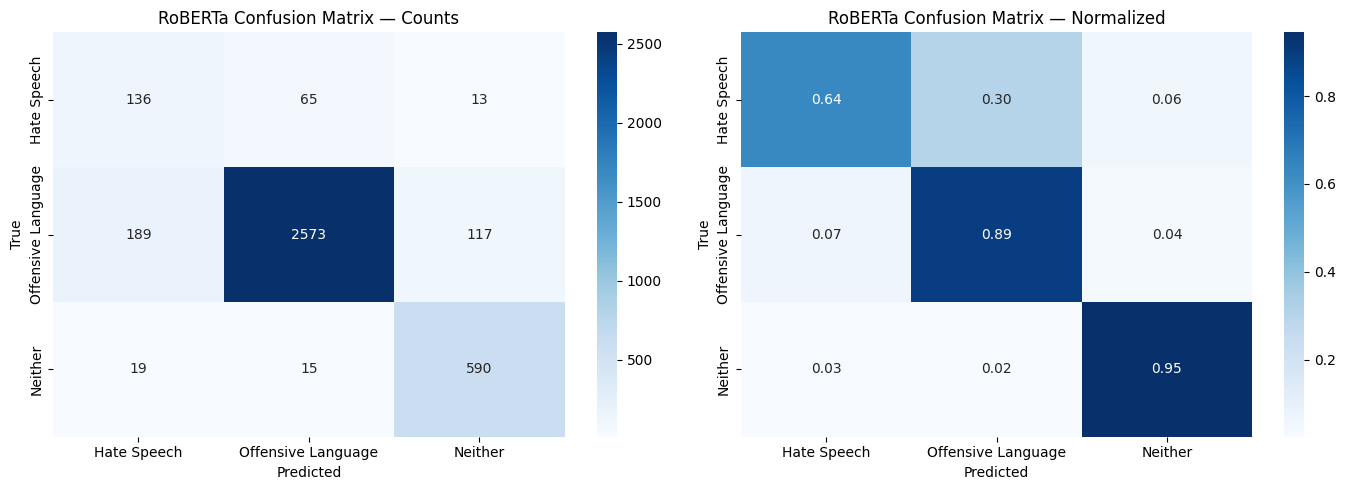

Confusion matrix saved to Drive.


In [ ]:
# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_f1, test_preds, test_labels = evaluate_model(
    model, test_loader, loss_fn, device
)

print("="*55)
print("FINAL TEST SET RESULTS — RoBERTa")
print("="*55)
print(classification_report(
    test_labels, test_preds,
    target_names=list(LABEL_NAMES.values())
))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Counts', 'Normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=LABEL_NAMES.values(),
                yticklabels=LABEL_NAMES.values(), ax=ax)
    ax.set_title(f'RoBERTa Confusion Matrix — {title}')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'roberta_confusion_matrix.png'), dpi=150)
plt.show()
print("Confusion matrix saved to Drive.")

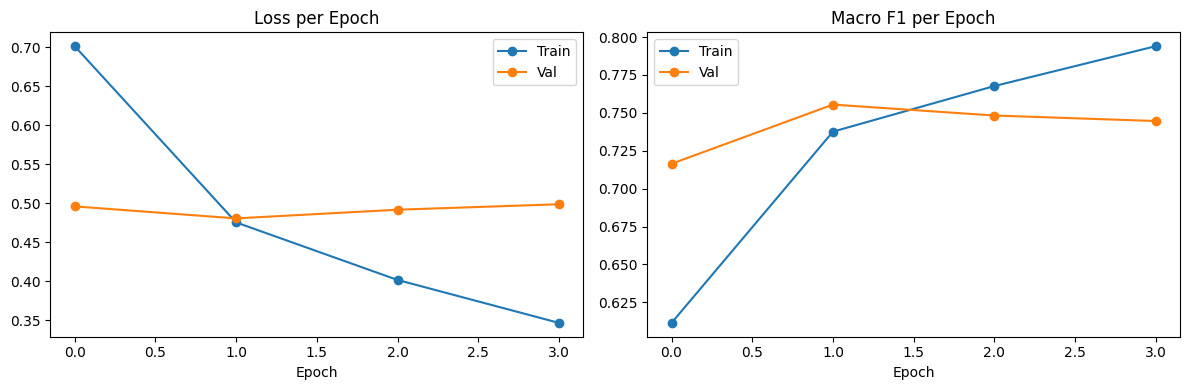


All files saved to Google Drive:
  /content/drive/MyDrive/hate-speech-project/models/roberta_best.pt
  /content/drive/MyDrive/hate-speech-project/models/roberta_tokenizer/
  /content/drive/MyDrive/hate-speech-project/models/roberta_training_history.csv
  /content/drive/MyDrive/hate-speech-project/models/roberta_confusion_matrix.png
  /content/drive/MyDrive/hate-speech-project/models/roberta_training_curves.png


In [ ]:
# Save tokenizer alongside model
tokenizer.save_pretrained(os.path.join(MODEL_PATH, 'roberta_tokenizer'))

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(MODEL_PATH, 'roberta_training_history.csv'),
                  index=False)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train', marker='o')
ax1.plot(history['val_loss'],   label='Val',   marker='o')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['train_f1'], label='Train', marker='o')
ax2.plot(history['val_f1'],   label='Val',   marker='o')
ax2.set_title('Macro F1 per Epoch')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'roberta_training_curves.png'), dpi=150)
plt.show()

print("\nAll files saved to Google Drive:")
print(f"  {MODEL_PATH}/roberta_best.pt")
print(f"  {MODEL_PATH}/roberta_tokenizer/")
print(f"  {MODEL_PATH}/roberta_training_history.csv")
print(f"  {MODEL_PATH}/roberta_confusion_matrix.png")
print(f"  {MODEL_PATH}/roberta_training_curves.png")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers -q

import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DRIVE_PATH = '/content/drive/MyDrive/hate-speech-project'
MODEL_PATH = os.path.join(DRIVE_PATH, 'models')
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


In [ ]:
MODEL_NAME     = 'roberta-base'
NUM_CLASSES    = 3
best_model_path = os.path.join(MODEL_PATH, 'roberta_best.pt')

# Reload tokenizer and model architecture
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

# Load our fine-tuned weights
state_dict = torch.load(best_model_path, map_location=device)
model.load_state_dict(state_dict, strict=True)
model = model.to(device)
model.eval()
print("Model loaded successfully!")

# Save properly using HuggingFace format
SAVE_PATH = os.path.join(MODEL_PATH, 'roberta_final')
os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"\nSaved to: {SAVE_PATH}")
print(f"Files: {os.listdir(SAVE_PATH)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved to: /content/drive/MyDrive/hate-speech-project/models/roberta_final
Files: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']
